In [1]:
import pandas as pd
import chardet
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

In [2]:
# Функция для загрузки одного файла
def load_csv(file_path, decimal='.'):
    # Определяем кодировку
    with open(file_path, 'rb') as f:
        encoding = chardet.detect(f.read())['encoding']
    
    # Загружаем файл
    df = pd.read_csv(file_path, encoding=encoding, sep=';', decimal=decimal)
    return df

# 2. Функция для создания признаков окна
def create_window_features(series, window_size=10):
    df_rolled = pd.DataFrame()
    df_rolled['mean'] = series.rolling(window=window_size).mean()
    df_rolled['median'] = series.rolling(window=window_size).median()
    df_rolled['std'] = series.rolling(window=window_size).std()
    # Можно добавить и другие признаки, например min и max [citation:5]
    # df_rolled['min'] = series.rolling(window=window_size).min()
    # df_rolled['max'] = series.rolling(window=window_size).max()
    
    # Удаляем строки с NaN (первые window_size-1 строк)
    return df_rolled.dropna()

In [3]:
# Загружаем все 5 файлов
df1 = load_csv('data/1.csv')
df2 = load_csv('data/2.csv')
df3 = load_csv('data/3.csv', decimal=',')
df4 = load_csv('data/4.csv')
df5 = load_csv('data/5.csv')

# Удаляем пустой столбец из df3
df3.drop(df3.columns[40], axis=1, inplace=True)

df2.columns = [i[3:] for i in df2.columns]
df4.columns = [i[3:] for i in df4.columns]
df5.columns = [i[3:] for i in df5.columns]

dfs = [df1, df2, df4, df3, df5]

In [4]:
for df in dfs:
    print(df.shape)

(12659, 24)
(13720, 24)
(13743, 24)
(14896, 40)
(38089, 24)


In [5]:
# Приводим столбец времени к одному названию "t" и переводим время в python-объект для удобной работы
for df in dfs:
    cols = df.columns.tolist()
    cols[0] = 't'
    df.columns = cols
    df['t'] = pd.to_datetime(df["t"], format='%H:%M:%S.%f').dt.time

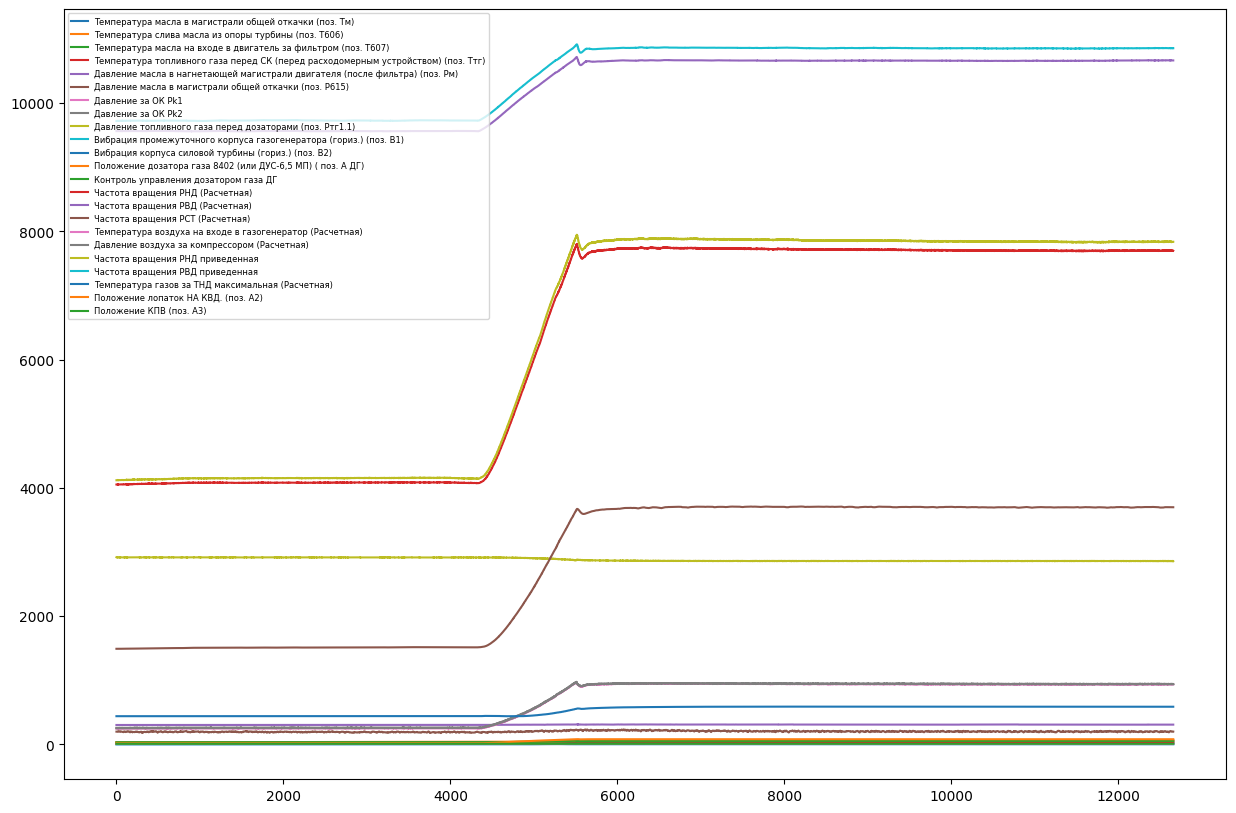

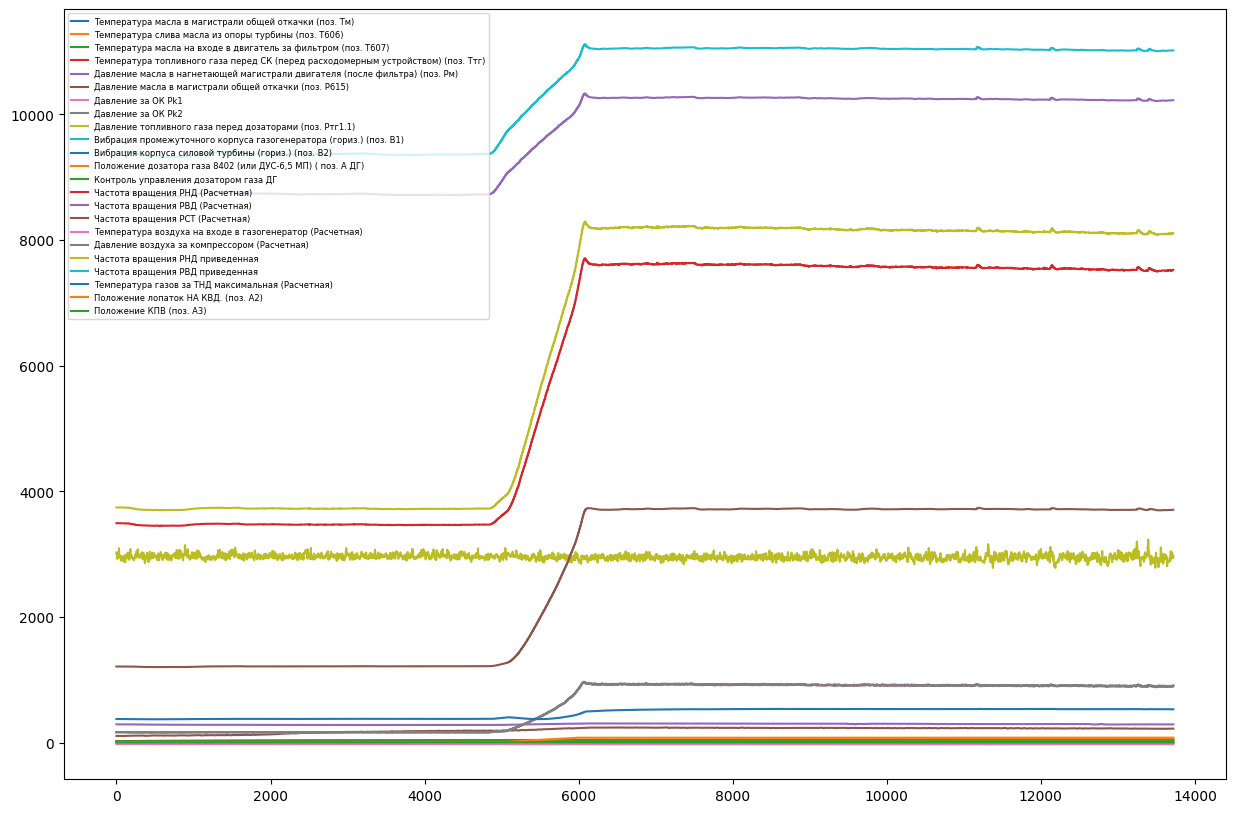

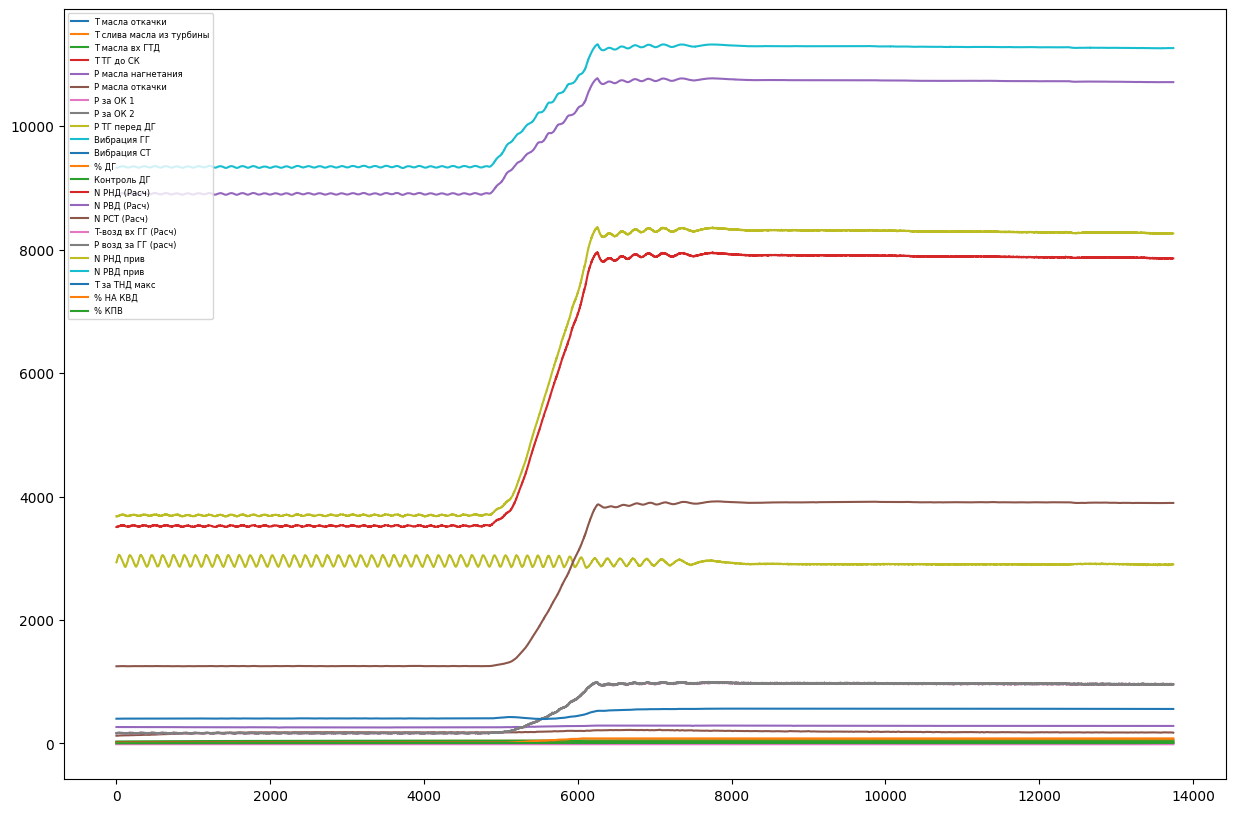

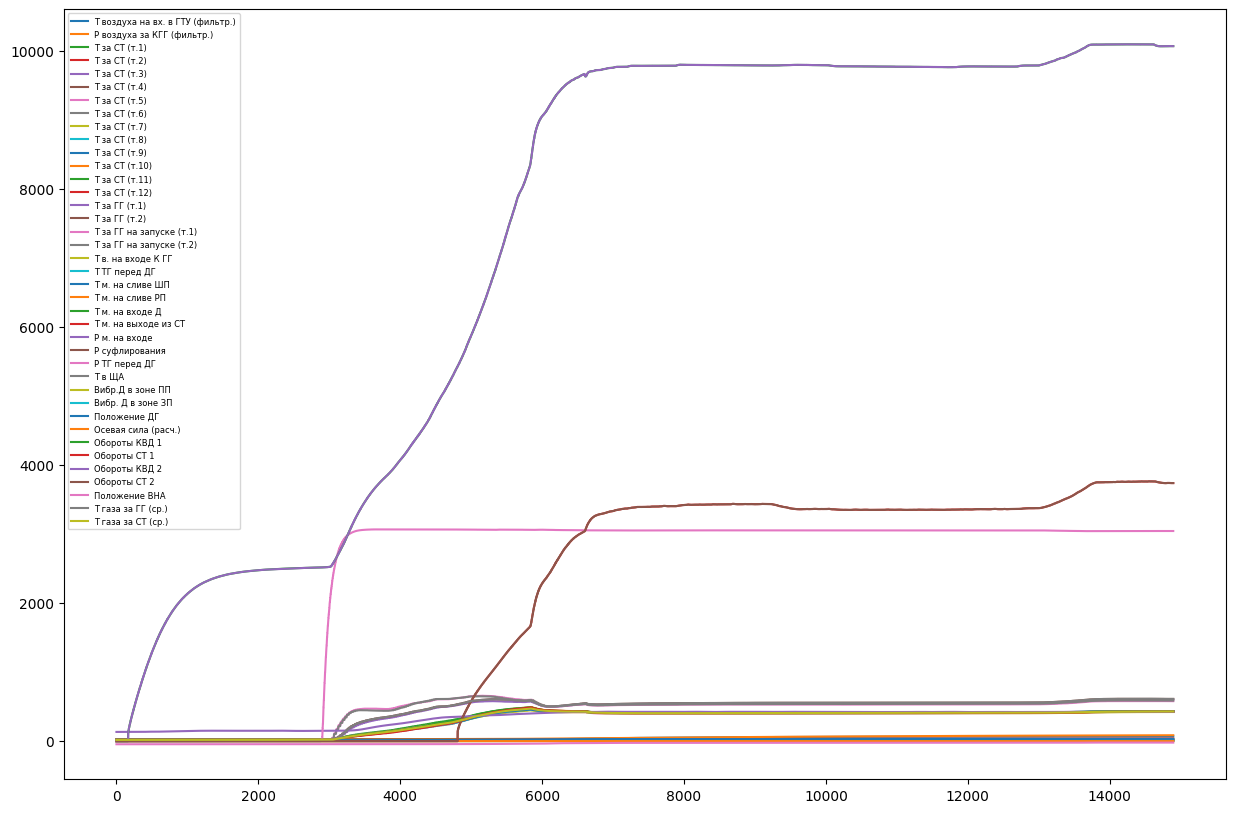

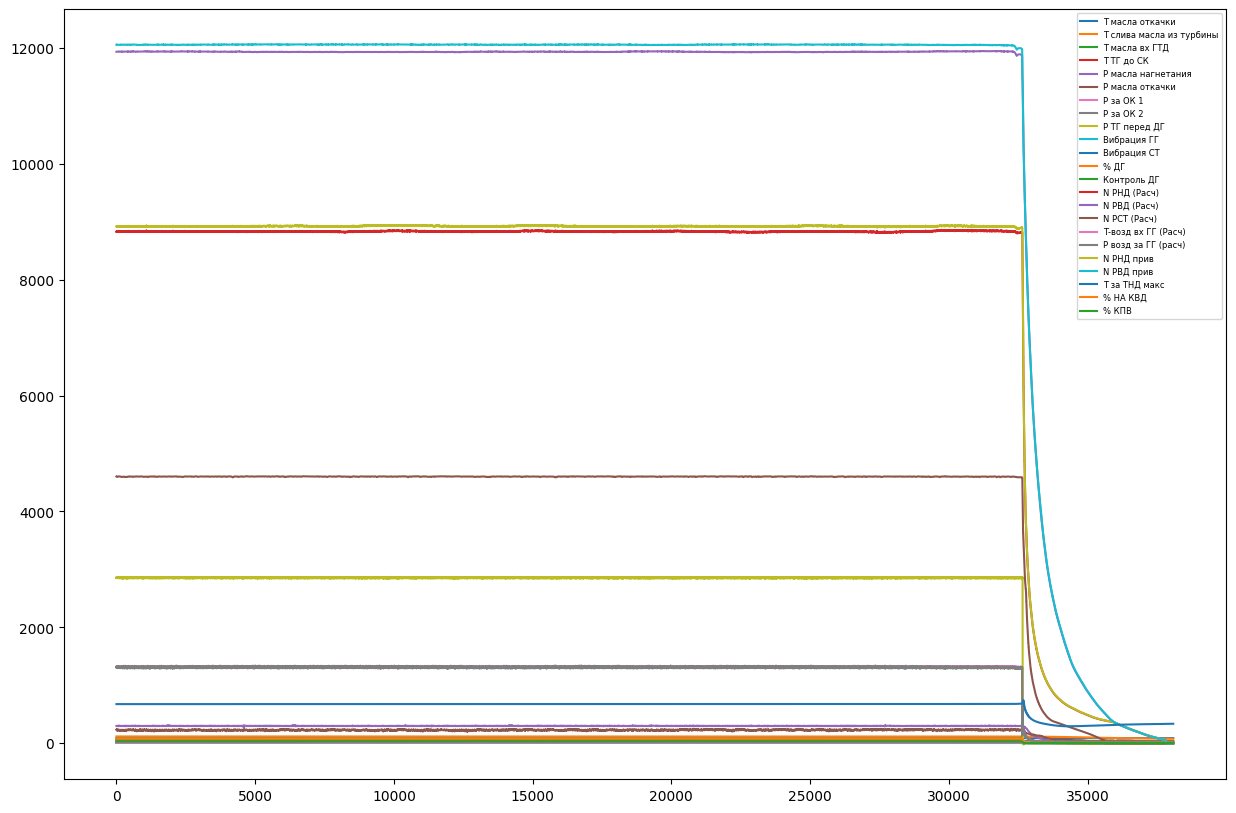

In [6]:
for df in dfs:
    df.plot(figsize=(15, 10))
    plt.legend(fontsize=6)
    plt.show()

In [7]:
all_series = sorted([pd.Series(df[column]) for df in dfs for column in df.columns[1:]], key=lambda x: x.name, reverse=True)
# Превращаем в производные (первая разность)
# all_series = [
#     series.diff().dropna()  # diff() вычисляет разности, dropna() убирает первый NaN
#     for series in all_series
# ]

In [8]:
groups = {
    'freq': all_series[:10],
    'temp': all_series[10:60],
    'pres': all_series[60:74] + all_series[91:103] + all_series[113:115],
    'pos': all_series[74:82],
    'axis': all_series[82:83],
    'rev': all_series[83:87],
    'ctl': all_series[87:91],
    'vibr': all_series[103:113],
    'n': all_series[115:125],
    'perc': all_series[125:131],
}

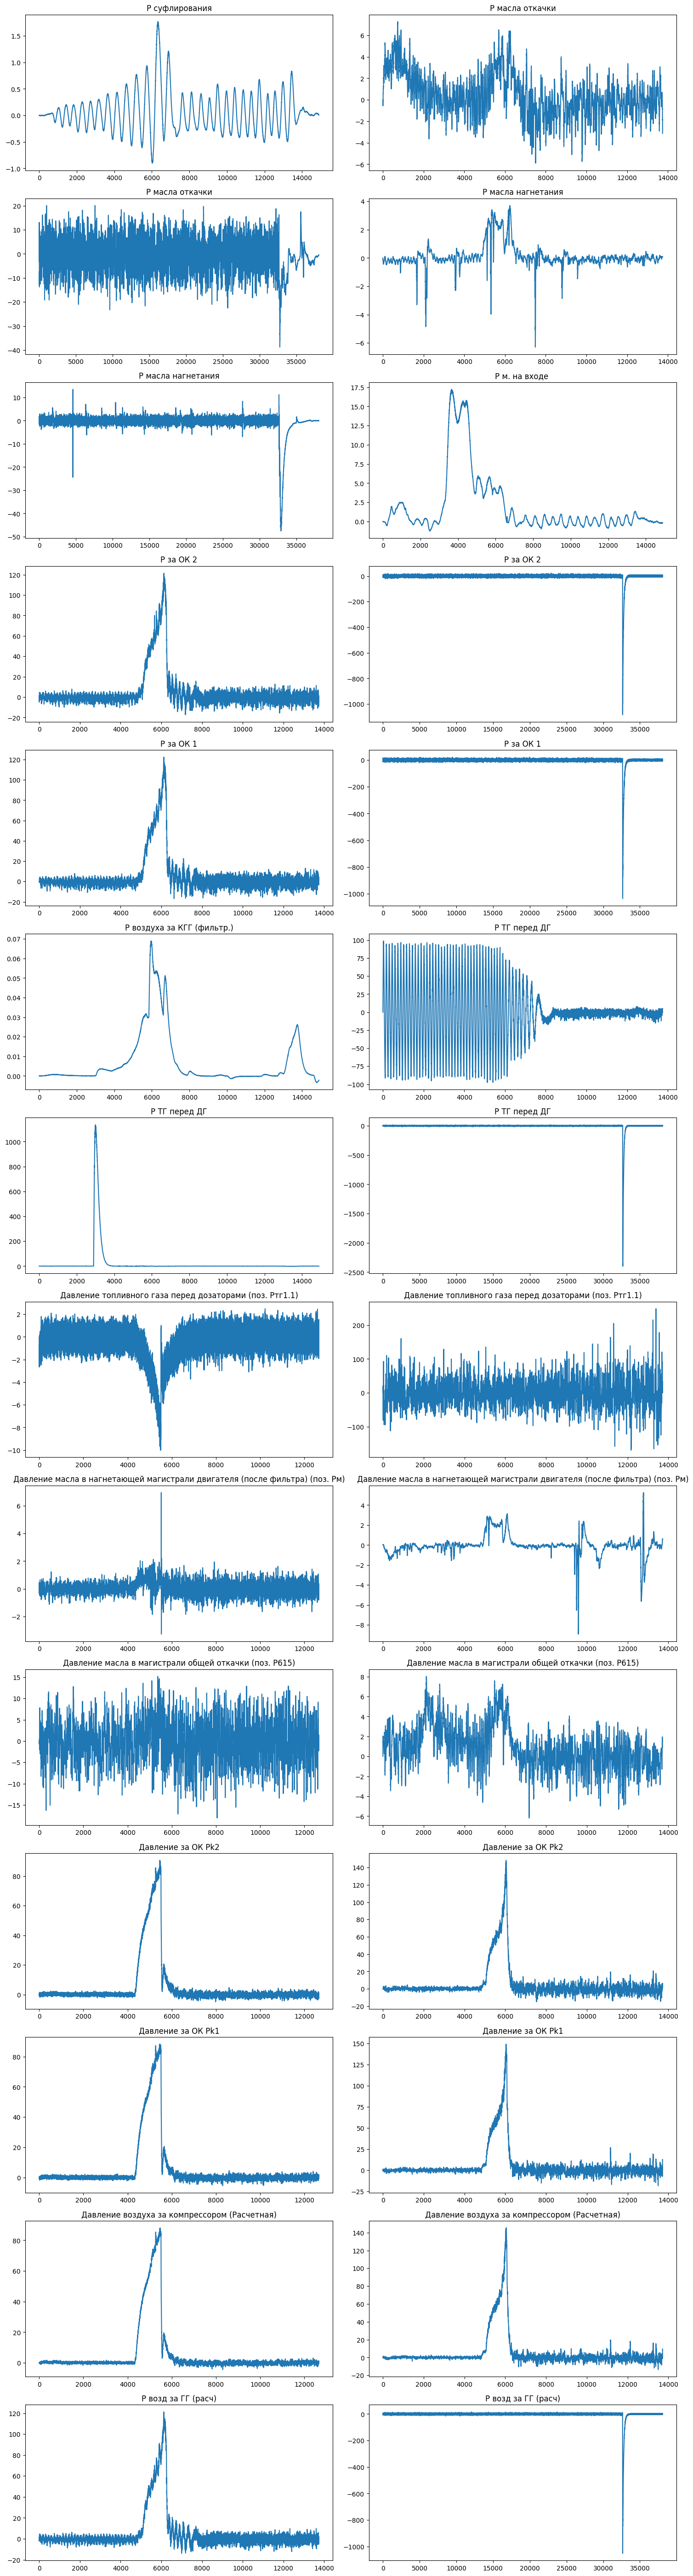

In [16]:
import matplotlib.pyplot as plt
import math

# Настройки сетки
n_series = len(all_series)
cols = 2  # Количество колонок
rows = math.ceil(n_series / cols) # Авто-расчет количества строк

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = axes.flatten() # Превращаем матрицу осей в плоский список

for i, series in enumerate(groups['pres']):
    new_series = series - series.ewm(alpha=0.01, adjust=False).mean()
    new_series.plot(ax=axes[i])
    axes[i].set_title(series.name)

# Удаляем пустые пустые графики, если количество серий не кратно колонкам
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

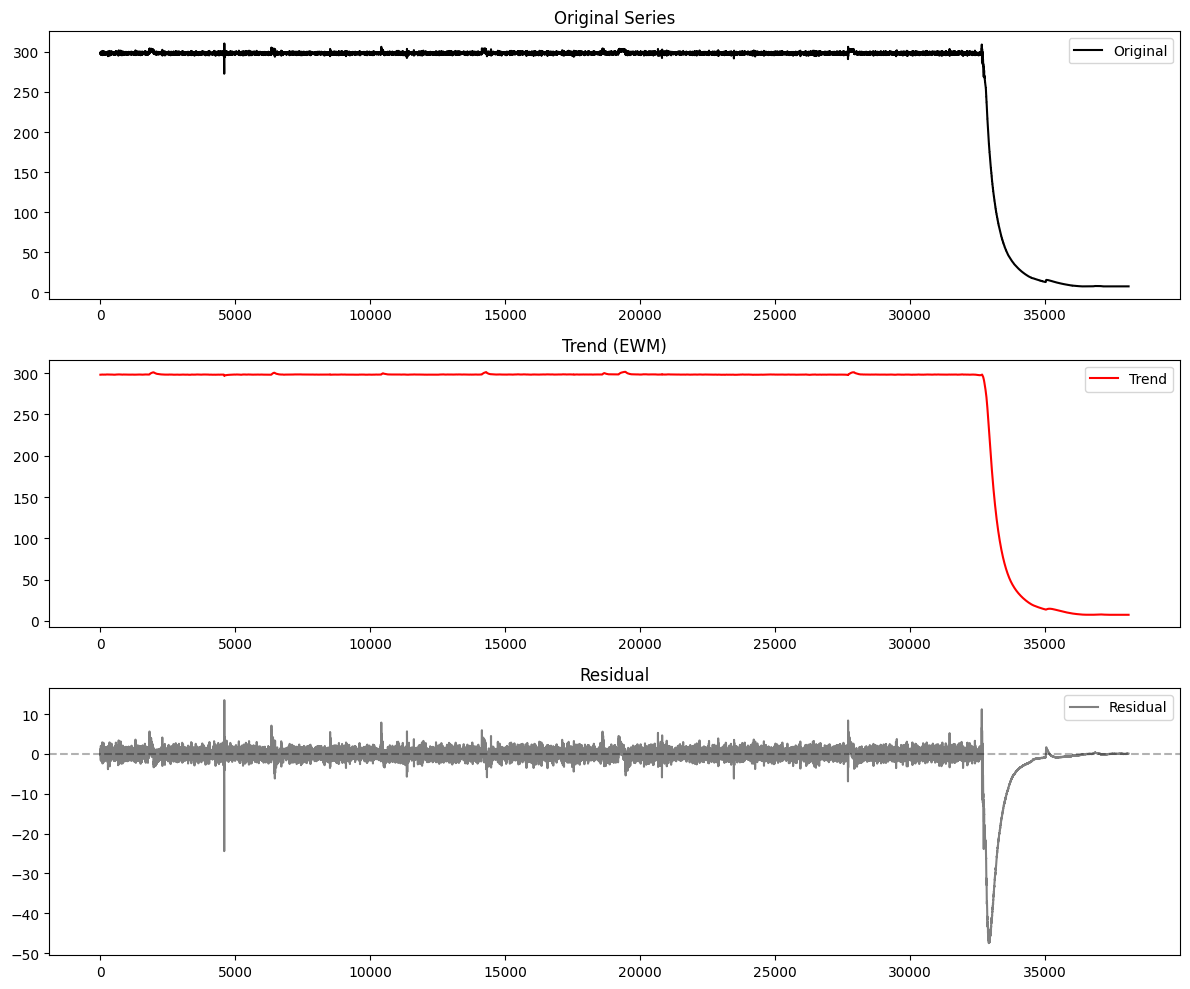

In [9]:
ser = groups['pres'][4]
df_rolled = pd.DataFrame(index=ser.index)

# Параметры
alpha_trend = 0.01

# Компоненты
df_rolled['trend'] = ser.ewm(alpha=alpha_trend, adjust=False).mean()
df_rolled['residual'] = ser - df_rolled['trend']

# Визуализация
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
axes[0].plot(ser.index, ser.values, label='Original', color='black')
axes[0].set_title('Original Series')
axes[0].legend()

axes[1].plot(df_rolled.index, df_rolled['trend'], label='Trend', color='red')
axes[1].set_title('Trend (EWM)')
axes[1].legend()

axes[2].plot(df_rolled.index, df_rolled['residual'], label='Residual', color='gray')
axes[2].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[2].set_title('Residual')
axes[2].legend()

plt.tight_layout()
plt.show()

In [10]:

# Предположим, df_rolled['residual'] — это твой ряд остатков
window_size = 50

# 1. Расчет RMS (Root Mean Square)
# Корень из среднего квадратов
features_df = pd.DataFrame()
features_df['rms'] = np.sqrt(
    df_rolled['residual'].pow(2).rolling(window=window_size).mean()
)

# 2. Расчет ABS Change (Среднее абсолютное изменение)
# Среднее разностей между соседними точками
features_df['abs_change'] = (
    df_rolled['residual'].diff().abs().rolling(window=window_size).mean()
)

# 3. Расчет ZCR (Zero Crossing Rate)
# Считаем, сколько раз сигнал меняет знак внутри окна
def calculate_zcr(window):
    # Умножаем соседние элементы: если результат < 0, значит знак изменился
    # Используем вычитание среднего, чтобы ZCR был точным, если остаток чуть смещен
    centered = window - window.mean()
    return ((centered[:-1] * centered[1:]) < 0).sum()

features_df['zcr'] = (
    df_rolled['residual'].rolling(window=window_size).apply(calculate_zcr, raw=True)
)

# Удаляем первые 49 строк, так как в них еще нет полных данных для окна (будут NaN)
features_df = features_df.dropna()


print(features_df.head())

         rms  abs_change   zcr
50  0.897387    0.565714  14.0
51  0.920483    0.555019  14.0
52  0.914996    0.589198  15.0
53  0.950624    0.620145  15.0
54  0.986273    0.617806  14.0


In [25]:
from sklearn.preprocessing import StandardScaler

# Инициализируем скалер
scaler = StandardScaler()

# Обучаем скалер и трансформируем данные
X_train = scaler.fit_transform(features_df)

# Теперь X_train — это матрица (N, 3), готовенькая для обучения автоэнкодера
print(X_train[:5])

[[-0.17810052  0.23562826  0.727943  ]
 [-0.17274239  0.19257573  0.727943  ]
 [-0.17401532  0.33015419  1.0443557 ]
 [-0.16574996  0.45472483  1.0443557 ]
 [-0.15747985  0.44530801  0.727943  ]]


In [26]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.preprocessing import StandardScaler

In [24]:
input_dim = X_train_scaled.shape[1] # Например, 3 (наши метрики)
encoding_dim = 2 # Сжимаем до 2-х "скрытых смыслов"

# Архитектура
input_layer = Input(shape=(input_dim,))
# Кодируем
encoded = Dense(encoding_dim, activation='relu')(input_layer)
# Декодируем (восстанавливаем)
decoded = Dense(input_dim, activation='linear')(encoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

# Обучаем (модель учится восстанавливать саму себя)
autoencoder.fit(X_train_scaled, X_train_scaled, 
                epochs=5, 
                batch_size=16, 
                shuffle=True, 
                verbose=0)

In [15]:
def check_current_window(window_data, scaler, autoencoder, threshold):
    """
    Принимает 50 последних точек остатка (residue)
    """
    # 1. Считаем метрики для этого конкретного окна
    rms = np.sqrt(np.mean(window_data**2))
    abs_change = np.mean(np.abs(np.diff(window_data)))
    
    centered = window_data - np.mean(window_data)
    zcr = ((centered[:-1] * centered[1:]) < 0).sum()
    
    f = np.array([rms, abs_change, zcr])
    
    # 2. Нормализуем (используем уже обученный scaler)
    f_scaled = scaler.transform([f])
    
    # 3. Прогоняем через автоэнкодер
    f_rec = autoencoder.predict(f_scaled, verbose=0)
    
    # 4. Считаем ошибку
    error = np.mean(np.power(f_scaled - f_rec, 2))
    
    return error > threshold, error

# ПРИМЕР: Берем последние 50 точек из нашего ряда
last_50_points = df_rolled['residual'].iloc[-50:].values
is_anomaly, score = check_current_window(last_50_points, scaler, autoencoder, 1)

print(f"Аномалия: {is_anomaly}, Ошибка: {score}")

Аномалия: True, Ошибка: 126.32691550794011
